**Regression model evaluation**

In this notebook we will look at **evaluation of regression models**.

Import `numpy`.

In [1]:
import numpy as np

Create a dataset for our little experiments.

In [2]:
np.random.seed(42)
n = 50
X = 2 * np.random.rand(n, 1)
y = 4 + 3 * X + np.random.randn(n, 1)

Visualize the data.

In [3]:
import matplotlib.pyplot as plt

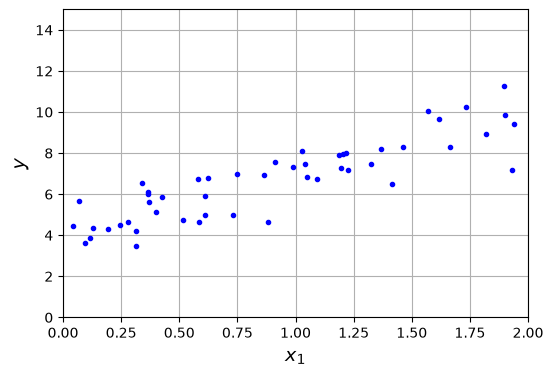

In [4]:
plt.figure(figsize=(6, 4))
plt.plot(X, y, 'b.')
plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.show()

Create a first degree Linear Regression model and evaluate it on the training data (don't trust the results).

In [5]:
from sklearn.linear_model import LinearRegression

In [6]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.09668927]), array([[2.888283]]))

We will compute MSE and $R^2$:

In [7]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

In [8]:
yHat = lin_reg.predict(X)

MAE = mean_absolute_error(y, yHat)
MSE = mean_squared_error(y, yHat)
RMSE = root_mean_squared_error(y, yHat)
R2 = r2_score(y, yHat)

print('Evaluation on training data:')
print('MAE:  %.3f' % MAE)
print('MSE:  %.3f' % MSE)
print('RMSE: %.3f' % RMSE)
print('R^2:  %.3f' % R2)

Evaluation on training data:
MAE:  0.731
MSE:  0.823
RMSE: 0.907
R^2:  0.768


---

# **Hold-out** (or *train-test split* is scikit-learn)

Import `train_test_split`.

In [9]:
from sklearn.model_selection import train_test_split

Split the data into training subset and validation subset with proportion 70:30.

In [10]:
X_train, X_validation, y_train, y_validation = train_test_split(
    X, y, test_size=0.3, random_state=42)  # it uses random number generator to split the data randomly

Create a model using the training data.

In [11]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_reg.intercept_, lin_reg.coef_

(array([4.2474045]), array([[2.80021836]]))

Evaluate the model on the validation data.

In [12]:
yHat = lin_reg.predict(X_validation)

MAE = mean_absolute_error(y_validation, yHat)
MSE = mean_squared_error(y_validation, yHat)
RMSE = root_mean_squared_error(y_validation, yHat)
R2 = r2_score(y_validation, yHat)

print('Evaluation on validation data:')
print('MAE:  %.3f' % MAE)
print('MSE:  %.3f' % MSE)
print('RMSE: %.3f' % RMSE)
print('R^2:  %.3f' % R2)

Evaluation on validation data:
MAE:  0.695
MSE:  0.779
RMSE: 0.882
R^2:  0.750


Visualize the data together with the model.

In [13]:
X_plot = np.linspace(np.min(X), np.max(X), 100).reshape(100, 1)
y_plot = lin_reg.predict(X_plot)  # predicting the output for each value

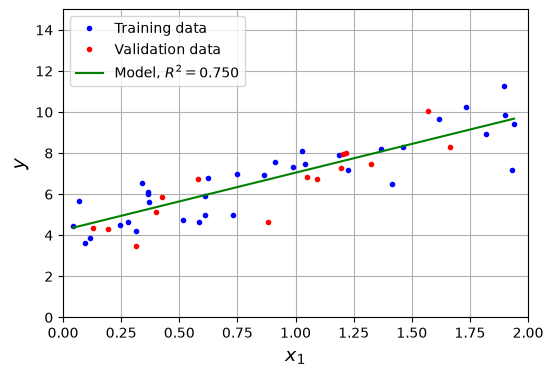

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(X_train, y_train, 'b.', label='Training data')
plt.plot(X_validation, y_validation, 'r.', label='Validation data')
plt.plot(X_plot, y_plot, 'g-', label='Model, $R^2=%.3f$' % R2)
plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.legend(loc='upper left')
plt.axis([0, 2, 0, 15])
plt.grid()
plt.show()

---

# **k-fold Cross-Validation**
Import `KFold`.

In [15]:
from sklearn.model_selection import KFold

Let's see what `KFold` is doing:

In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # define 5-fold Cross-Validation. Shuffle before splitting
data = np.array(['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j'])
for train_idx, validation_idx in kf.split(data):
    print("Training indices: %s, Validation indices: %s, Actual training: %s, Actual validation: %s" %
     (train_idx, validation_idx, data[train_idx], data[validation_idx]))

Training indices: [0 2 3 4 5 6 7 9], Validation indices: [1 8], Actual training: ['a' 'c' 'd' 'e' 'f' 'g' 'h' 'j'], Actual validation: ['b' 'i']
Training indices: [1 2 3 4 6 7 8 9], Validation indices: [0 5], Actual training: ['b' 'c' 'd' 'e' 'g' 'h' 'i' 'j'], Actual validation: ['a' 'f']
Training indices: [0 1 3 4 5 6 8 9], Validation indices: [2 7], Actual training: ['a' 'b' 'd' 'e' 'f' 'g' 'i' 'j'], Actual validation: ['c' 'h']
Training indices: [0 1 2 3 5 6 7 8], Validation indices: [4 9], Actual training: ['a' 'b' 'c' 'd' 'f' 'g' 'h' 'i'], Actual validation: ['e' 'j']
Training indices: [0 1 2 4 5 7 8 9], Validation indices: [3 6], Actual training: ['a' 'b' 'c' 'e' 'f' 'h' 'i' 'j'], Actual validation: ['d' 'g']


Evaluate the first degree polynomial on the data using 5-fold Cross-Validation.

In [17]:
lin_reg = LinearRegression()

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)  # define k-fold Cross-Validation. Shuffle before splitting

MSECV = 0
R2CV = 0

print('Results for separate folds:')

for train_idx, validation_idx in kf.split(X, y):  # loop through all folds
  # from indices to actual data subsets
  X_train = X[train_idx]
  y_train = y[train_idx]
  X_validation = X[validation_idx]
  y_validation = y[validation_idx]

  # train Linear Regression on training data
  lin_reg.fit(X_train, y_train)

  # do predictions on validation data
  yHat = lin_reg.predict(X_validation)
  MSE = mean_squared_error(y_validation, yHat)
  MSECV += MSE
  R2 = r2_score(y_validation, yHat)
  R2CV += R2
  print('MSE: %.3f' % MSE)
  print('R^2: %.3f' % R2)

print('Cross-validation final result:')
print('MSE: %.3f' % (MSECV / k))
print('R^2: %.3f' % (R2CV / k))

Results for separate folds:
MSE: 0.796
R^2: 0.698
MSE: 0.525
R^2: 0.815
MSE: 1.896
R^2: 0.482
MSE: 0.386
R^2: 0.930
MSE: 0.708
R^2: 0.751
Cross-validation final result:
MSE: 0.862
R^2: 0.735


Let's make the code into a function so that we can reuse it for different models.

In [18]:
def k_fold_cv(X, y, model, k):
  kf = KFold(n_splits=k, shuffle=True, random_state=42)  # define k-fold Cross-Validation. Shuffle before splitting

  MSECV = 0
  R2CV = 0

  for train_idx, validation_idx in kf.split(X, y):  # loop through all folds
    # from indices to actual data subsets
    X_train = X[train_idx]
    y_train = y[train_idx]
    X_validation = X[validation_idx]
    y_validation = y[validation_idx]

    # train Linear Regression on training data
    model.fit(X_train, y_train)

    # do predictions on validation data
    yHat = model.predict(X_validation)
    MSE = mean_squared_error(y_validation, yHat)
    MSECV += MSE
    R2 = r2_score(y_validation, yHat)
    R2CV += R2

  return MSECV / k, R2CV / k

Using the function:

In [19]:
MSE, R2 = k_fold_cv(X, y, LinearRegression(), 5)

print('Cross-validation result for 1st degree polynomial:')
print('MSE: %.3f' % MSE)
print('R^2: %.3f' % R2)

Cross-validation result for 1st degree polynomial:
MSE: 0.862
R^2: 0.735


In [20]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

MSE, R2 = k_fold_cv(X_poly, y, LinearRegression(), 5)

print('Cross-validation result for 2nd degree polynomial:')
print('MSE: %.3f' % MSE)
print('R^2: %.3f' % R2)

Cross-validation result for 2nd degree polynomial:
MSE: 0.919
R^2: 0.716


Actually, of course, we don't have to write our own function for that. We can use `cross_val_score`:

In [21]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(LinearRegression(), X_poly, y, cv=5, scoring='r2')
scores.mean()

np.float64(0.7327490126564635)

In [22]:
from sklearn.model_selection import cross_validate
scores = cross_validate(LinearRegression(), X_poly, y, cv=5, scoring=['neg_mean_squared_error', 'r2'])
scores

{'fit_time': array([0.00141096, 0.00061893, 0.00044298, 0.00078487, 0.00040698]),
 'score_time': array([0.00073218, 0.00052476, 0.00205183, 0.00049615, 0.00037098]),
 'test_neg_mean_squared_error': array([-0.93117436, -0.55034403, -0.85161184, -1.64241067, -0.53419756]),
 'test_r2': array([0.81936672, 0.71706698, 0.77535353, 0.66470256, 0.68725526])}

In [23]:
print('MSE:', -scores['test_neg_mean_squared_error'].mean())
print('R2:', scores['test_r2'].mean())

MSE: 0.9019476927386831
R2: 0.7327490126564635


---

# **Leave-One-Out Cross-Validation**
Import `LeaveOneOut`.

In [24]:
from sklearn.model_selection import LeaveOneOut

Let's see what `LeaveOneOut` is doing:

In [25]:
loo = LeaveOneOut()
data = np.array(['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j'])
for train_idx, validation_idx in loo.split(data):
    print("Training indices: %s, Validation indices: %s, Actual training: %s, Actual validation: %s" %
     (train_idx, validation_idx, data[train_idx], data[validation_idx]))

Training indices: [1 2 3 4 5 6 7 8 9], Validation indices: [0], Actual training: ['b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j'], Actual validation: ['a']
Training indices: [0 2 3 4 5 6 7 8 9], Validation indices: [1], Actual training: ['a' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j'], Actual validation: ['b']
Training indices: [0 1 3 4 5 6 7 8 9], Validation indices: [2], Actual training: ['a' 'b' 'd' 'e' 'f' 'g' 'h' 'i' 'j'], Actual validation: ['c']
Training indices: [0 1 2 4 5 6 7 8 9], Validation indices: [3], Actual training: ['a' 'b' 'c' 'e' 'f' 'g' 'h' 'i' 'j'], Actual validation: ['d']
Training indices: [0 1 2 3 5 6 7 8 9], Validation indices: [4], Actual training: ['a' 'b' 'c' 'd' 'f' 'g' 'h' 'i' 'j'], Actual validation: ['e']
Training indices: [0 1 2 3 4 6 7 8 9], Validation indices: [5], Actual training: ['a' 'b' 'c' 'd' 'e' 'g' 'h' 'i' 'j'], Actual validation: ['f']
Training indices: [0 1 2 3 4 5 7 8 9], Validation indices: [6], Actual training: ['a' 'b' 'c' 'd' 'e' 'f' 'h' 'i' 'j'], Actual val

In [26]:
def loocv(X, y, model):
  loo = LeaveOneOut()  # define LOOCV

  yHat = np.empty(y.size)  # this will be filled with predictions for us to compute scores after the loop

  for train_idx, validation_idx in loo.split(X, y):  # loop through all folds
    # from indices to actual data subsets
    X_train = X[train_idx]
    y_train = y[train_idx]
    X_validation = X[validation_idx]
    y_validation = y[validation_idx]

    # train Linear Regression on training data
    model.fit(X_train, y_train)

    # do prediction on the one validation data point
    yHat[validation_idx] = model.predict(X_validation)

  MSE = mean_squared_error(y, yHat)
  R2 = r2_score(y, yHat)

  return MSE, R2

In [27]:
MSE, R2 = loocv(X, y, LinearRegression())

print('LOOCV result for 1st degree polynomial:')
print('MSE: %.3f' % MSE)
print('R^2: %.3f' % R2)

LOOCV result for 1st degree polynomial:
MSE: 0.908
R^2: 0.744


In [28]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

MSE, R2 = loocv(X_poly, y, LinearRegression())

print('LOOCV result:')
print('MSE: %.3f' % MSE)
print('R^2: %.3f' % R2)

LOOCV result:
MSE: 0.967
R^2: 0.728


Actually, of course, we don't have to write our own function for that. We can use `cross_val_predict`:

In [29]:
from sklearn.model_selection import cross_val_predict

yHat = cross_val_predict(LinearRegression(), X_poly, y, cv=n)

MSE = mean_squared_error(y, yHat)
R2 = r2_score(y, yHat)

print('LOOCV result:')
print('MSE:  %.3f' % MSE)
print('R^2:  %.3f' % R2)

LOOCV result:
MSE:  0.967
R^2:  0.728


---

# **Underfitting, overfitting**

*You will look into this in your practical assignment.*

---

# **Learning curves**

A [learning curve](https://en.wikipedia.org/wiki/Learning_curve_(machine_learning)) is a graphical plot that tracks a model's performance (such as error, loss, or accuracy) on both training and validation sets over time, epochs, or training set size.

We will track RMSE over training set size.

Let's use the curves to determine whether a model overfits the data and how much it could benefit from adding more training data.

In [30]:
from sklearn.pipeline import make_pipeline

def PolynomialRegression(degree, **kwargs):
    return make_pipeline(PolynomialFeatures(degree, include_bias=False), LinearRegression(**kwargs))

from sklearn.model_selection import learning_curve

def plot_learning_curve(degree):
  train_sizes = np.linspace(0.05, 1, 30)
  N_train, val_train, val_test = learning_curve(
      PolynomialRegression(degree), X, y, train_sizes=train_sizes,
      cv=10, shuffle=True, random_state=1, scoring='neg_root_mean_squared_error')
  plt.figure(figsize=(6, 4))
  plt.plot(N_train, -val_train.mean(axis=1), label='Training error')
  plt.plot(N_train, -val_test.mean(axis=1), label='Validation error')
  plt.xlabel('Training Set Size');
  plt.ylabel('RMSE')
  plt.ylim(0, 2)
  plt.grid()
  plt.legend()

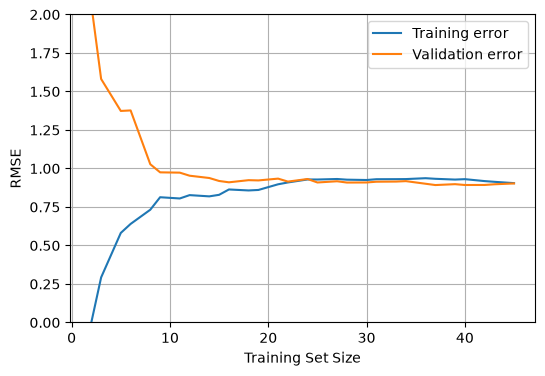

In [31]:
plot_learning_curve(1)

Here is an alternative implementation to using the `learning_curves()` function and getting a similar result:

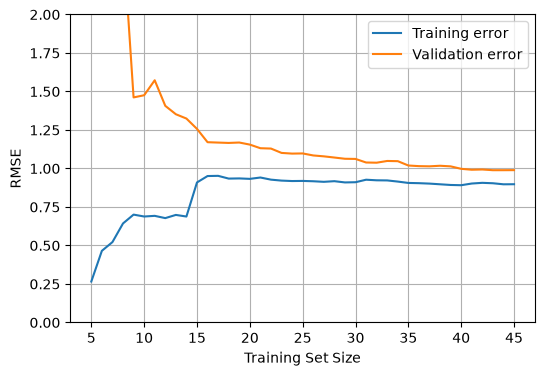

In [32]:
degree=3

n = len(y)
n_splits=10
max_train_size = int(n - n / n_splits) # this is maximum traing set size, because we use k-fold Cross-Validation
train_sizes = range(5, max_train_size + 1)
kf = KFold(n_splits=n_splits, shuffle=True, random_state=1) # prepare folds

from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=degree, include_bias=False)

RMSE_train = []
RMSE_validation = []

for train_size in train_sizes: # loop over the training set sizes

  RMSE_train_curr = []
  RMSE_validation_curr = []

  for train_idx, validation_idx in kf.split(X): # loop over k-fold Cross-Validation folds
    rng = np.random.RandomState(1)
    shuffled_train_idx = rng.permutation(train_idx)
    subset_idx = shuffled_train_idx[:train_size] # take a subset for training

    X_train = X[subset_idx]
    y_train = y[subset_idx]
    X_validation = X[validation_idx]
    y_validation = y[validation_idx]

    poly_features.fit(X_train)
    X_train = poly_features.transform(X_train)
    X_validation = poly_features.transform(X_validation)

    lin_reg = LinearRegression()
    lin_reg.fit(X_train, y_train)
    yHat = lin_reg.predict(X_validation)
    RMSE = root_mean_squared_error(y_validation, yHat) # evaluate on validation data
    RMSE_validation_curr.append(RMSE)

    yHat = lin_reg.predict(X_train)
    RMSE = root_mean_squared_error(y_train, yHat) # evaluate on training data
    RMSE_train_curr.append(RMSE)

  RMSE_validation.append(np.mean(RMSE_validation_curr))
  RMSE_train.append(np.mean(RMSE_train_curr))

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, RMSE_train, label='Training error')
plt.plot(train_sizes, RMSE_validation, label='Validation error')
plt.xlabel('Training Set Size');
plt.ylabel('RMSE')
plt.ylim(0, 2)
plt.legend()
plt.grid()
plt.show()

<br>
<br>
<br>
<br>
<br>
<br>

---
<small>*Notebook by Gints Jēkabsons*</small>